# CLASIFICACION ABC

**Autor: Abdias Figueredo V.**

**Version: 1.0**

**Agosto 2025**

**Cochabamba, Bolivia**

## Índice
1.  **Introducción**

2.  **Configuración Inicial**

3.  **Analisis Univariado**

4.  **Análisis de Distribuciones**

5.  **Análisis de Outliers**

7.  **Conclusiones**

## 1. INTRODUCCIÓN

Este proyecto tiene como objetivo realizar un Análisis Exploratorio de Datos (EDA) exhaustivo de los datos de ventas, productos e inventario de una empresa importadora de autopartes. La empresa maneja alrededor de 10,000 SKUs diferentes y tiene registros desde 2018 hasta la fecha actual, generados con IA simulando un sistema SAP Business One.

**Objetivos del EDA:**

*   Comprender la estructura y calidad de los datos disponibles.
*   Identificar patrones y tendencias en las ventas a lo largo del tiempo.
*   Analizar el comportamiento de los diferentes SKUs en términos de ventas y rotación de inventario.
*   Detectar posibles problemas en los datos, como valores atípicos o inconsistencias.
*   Generar hipótesis para futuros análisis y modelado predictivo.

**Tablas de Datos:**

*   **OITM (Tabla de Productos):** Contiene información detallada sobre cada producto, incluyendo su código, descripción, precio, etc.
*   **INV1 (Tabla de Ventas):** Registra las transacciones de venta, incluyendo la fecha, el SKU vendido, la cantidad, el precio, etc.
*   **OINM (Tabla de Inventario):** Contiene información sobre los movimientos de inventario, como entradas, salidas y ajustes.

---

## 2. CONFIGURACION INICIAL

### 2.1 Importación de librerías necesarias

In [ ]:
# INSTALACION DE REQUIREMENTS
# Comando alternativo: pip install -r requirements.txt
#!pip install -r requirements.txt --quiet
# pip install --only-binary :all: statsforecast

In [1]:
# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
# Manejo y procesamiento de datos
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import os
import scipy.stats as stats
from pandas.tseries.offsets import DateOffset

# Análisis de series temporales
# -----------------------------------------------------------------------------
from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Visualización
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración de advertencias
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilos de visualización
# =============================================================================
# Configuración general de matplotlib
plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (18, 7),
    'axes.facecolor': '#FFFFFF',  # Fondo blanco para mejor legibilidad
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Configuración de seaborn
#sns.set_theme(style="whitegrid", 
#              rc={'axes.facecolor': '#FFFFFF'},
#              font_scale=1.1)

c:\Users\abdia\AppData\Local\Programs\Python\Python313\Lib\site-packages\fs\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore
c:\Users\abdia\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.2 Carga de datos

In [ ]:
# =============================================================================
# CARGA DE DATOS
# =============================================================================
# Definición de rutas de archivos
DATA_DIR = '../data'
FILE_PATHS = {
    'oitm': os.path.join(DATA_DIR, 'oitm.parquet'),
    'inv1': os.path.join(DATA_DIR, 'inv1.parquet'),
    'oinm': os.path.join(DATA_DIR, 'oinm.parquet')
}

# Carga de datos con manejo de errores
try:
    # Cargar datos en un diccionario para mejor organización
    data = {
        'oitm': pd.read_parquet(FILE_PATHS['oitm']),
        'inv1': pd.read_parquet(FILE_PATHS['inv1']),
        'oinm': pd.read_parquet(FILE_PATHS['oinm'])
    }
    
    # Crear copias para procesamiento
    df_oitm = data['oitm'].copy()
    df_inv1 = data['inv1'].copy()
    df_oinm = data['oinm'].copy()
    
    # Verificación de carga exitosa
    print("✅ Datos cargados exitosamente")
    print(f"📊 Registros cargados:")
    print(f"   - oitm: {len(df_oitm):,} registros")
    print(f"   - inv1: {len(df_inv1):,} registros")
    print(f"   - oinm: {len(df_oinm):,} registros")
    
except Exception as e:
    print(f"❌ Error al cargar los datos: {str(e)}")
    # Opcional: cargar datos de respaldo o finalizar la ejecución
    raise

✅ Datos cargados exitosamente
📊 Registros cargados:
   - oitm: 10,000 registros
   - inv1: 1,000,000 registros
   - oinm: 1,100,000 registros


---

## 3. ANALISIS UNIVARIADO

### 3.1 Tabla Productos (OITM)

In [12]:
def display_dataframe_info(df, name, rows=5):
    """
    Muestra información detallada de un DataFrame de manera formateada.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame a mostrar
    name : str
        Nombre descriptivo del DataFrame
    rows : int, opcional
        Número de filas a mostrar (por defecto: 5)
    """
    # Título con formato
    print(f"\n{'='*80}")
    print(f"📋 INFORMACIÓN DEL DATAFRAME: {name.upper()}")
    print(f"{'='*80}")
    
    # Mostrar dimensiones
    print(f"📊 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    
    # Mostrar tipos de datos
    print("\n📝 Tipos de datos:")
    print(df.dtypes)
    
    # Mostrar primeras filas
    print(f"\n🔍 Primeras {rows} filas:")
    display(df.head(rows))
    
    # Mostrar estadísticas descriptivas
    print("\n📈 Estadísticas descriptivas:")
    display(df.describe(include='all'))
    
    # Mostrar valores nulos
    print("\n❓ Valores nulos por columna:")
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().mean() * 100).round(2)
    null_df = pd.DataFrame({
        'Valores nulos': null_counts,
        'Porcentaje (%)': null_percent
    })
    display(null_df[null_df['Valores nulos'] > 0] if null_df['Valores nulos'].sum() > 0 
            else "✅ No hay valores nulos")

# Uso de la función
display_dataframe_info(df_oitm, "Productos (OITM)")


📋 INFORMACIÓN DEL DATAFRAME: PRODUCTOS (OITM)
📊 Dimensiones: 10,000 filas x 5 columnas

📝 Tipos de datos:
ItemCode              object
ItemName              object
Brand                 object
Category              object
CreateDate    datetime64[ns]
dtype: object

🔍 Primeras 5 filas:


,ItemCode,ItemName,Brand,Category,CreateDate
0,SKU-00000,Guess total Part,Bishop Inc,disintermediate,2018-12-24 01:07:17
1,SKU-00001,Treat international Part,Velazquez Ltd,re-intermediate,2016-12-06 03:42:33
2,SKU-00002,Today be Part,"Huber, Norris and Walton",expedite,2015-12-30 23:39:24
3,SKU-00003,Paper simply Part,Merritt Ltd,optimize,2018-01-06 23:49:57
4,SKU-00004,Cup girl Part,Brooks Inc,strategize,2016-08-07 19:40:51



📈 Estadísticas descriptivas:


,ItemCode,ItemName,Brand,Category,CreateDate
count,10000,10000,10000,10000,10000
unique,10000,9946,8674,60,NaN
top,SKU-09983,Better pull Part,Johnson LLC,benchmark,NaN
freq,1,2,19,191,NaN
mean,NaN,NaN,NaN,NaN,2017-07-30 10:59:18.334699776
min,NaN,NaN,NaN,NaN,2015-08-03 18:17:39
25%,NaN,NaN,NaN,NaN,2016-08-06 06:44:00.249999872
50%,NaN,NaN,NaN,NaN,2017-07-28 13:41:12.500000
75%,NaN,NaN,NaN,NaN,2018-07-24 15:59:02.750000128
max,NaN,NaN,NaN,NaN,2019-08-03 12:17:41



❓ Valores nulos por columna:


'✅ No hay valores nulos'

### 3.2 Tabla de Ventas (INV1)

In [13]:
def display_dataframe_info(df, name, rows=5):
    """
    Muestra información detallada de un DataFrame de manera formateada.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame a mostrar
    name : str
        Nombre descriptivo del DataFrame
    rows : int, opcional
        Número de filas a mostrar (por defecto: 5)
    """
    # Título con formato
    print(f"\n{'='*80}")
    print(f"📋 INFORMACIÓN DEL DATAFRAME: {name.upper()}")
    print(f"{'='*80}")
    
    # Mostrar dimensiones
    print(f"📊 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    
    # Mostrar tipos de datos
    print("\n📝 Tipos de datos:")
    print(df.dtypes)
    
    # Mostrar primeras filas
    print(f"\n🔍 Primeras {rows} filas:")
    display(df.head(rows))
    
    # Mostrar estadísticas descriptivas
    print("\n📈 Estadísticas descriptivas:")
    display(df.describe(include='all'))
    
    # Mostrar valores nulos
    print("\n❓ Valores nulos por columna:")
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().mean() * 100).round(2)
    null_df = pd.DataFrame({
        'Valores nulos': null_counts,
        'Porcentaje (%)': null_percent
    })
    display(null_df[null_df['Valores nulos'] > 0] if null_df['Valores nulos'].sum() > 0 
            else "✅ No hay valores nulos")

# Uso de la función
display_dataframe_info(df_inv1, "Ventas (INV1)")


📋 INFORMACIÓN DEL DATAFRAME: VENTAS (INV1)
📊 Dimensiones: 1,000,000 filas x 7 columnas

📝 Tipos de datos:
DocEntry              int64
DocDate      datetime64[ns]
CardCode             object
ItemCode             object
Quantity              int64
Price               float64
LineTotal           float64
dtype: object

🔍 Primeras 5 filas:


,DocEntry,DocDate,CardCode,ItemCode,Quantity,Price,LineTotal
0,1,2025-02-26,C0103,SKU-09192,13,361.93,4705.09
1,2,2019-05-04,C1691,SKU-09361,6,279.73,1678.38
2,3,2018-09-25,C1838,SKU-00564,1,245.87,245.87
3,4,2024-06-17,C0672,SKU-08737,6,91.00,546.00
4,5,2024-07-05,C1202,SKU-03964,2,270.44,540.88



📈 Estadísticas descriptivas:


,DocEntry,DocDate,CardCode,ItemCode,Quantity,Price,LineTotal
count,1000000.000000,1000000,1000000,1000000,1000000.000000,1000000.000000,1000000.000000
unique,NaN,NaN,1999,10000,NaN,NaN,NaN
top,NaN,NaN,C1070,SKU-03590,NaN,NaN,NaN
freq,NaN,NaN,596,145,NaN,NaN,NaN
mean,500000.500000,2021-10-16 10:47:34.944000256,NaN,NaN,7.497606,252.219731,1890.433017
min,1.000000,2018-01-01 00:00:00,NaN,NaN,1.000000,5.000000,5.000000
25%,250000.750000,2019-11-24 00:00:00,NaN,NaN,4.000000,128.400000,575.815000
50%,500000.500000,2021-10-17 00:00:00,NaN,NaN,7.000000,252.250000,1442.965000
75%,750000.250000,2023-09-09 00:00:00,NaN,NaN,11.000000,375.882500,2855.160000
max,1000000.000000,2025-08-01 00:00:00,NaN,NaN,14.000000,500.000000,7000.000000



❓ Valores nulos por columna:


'✅ No hay valores nulos'

📊 Total de ítems únicos: 10,000
📈 Rango de cantidades: 1,038 - 1,116


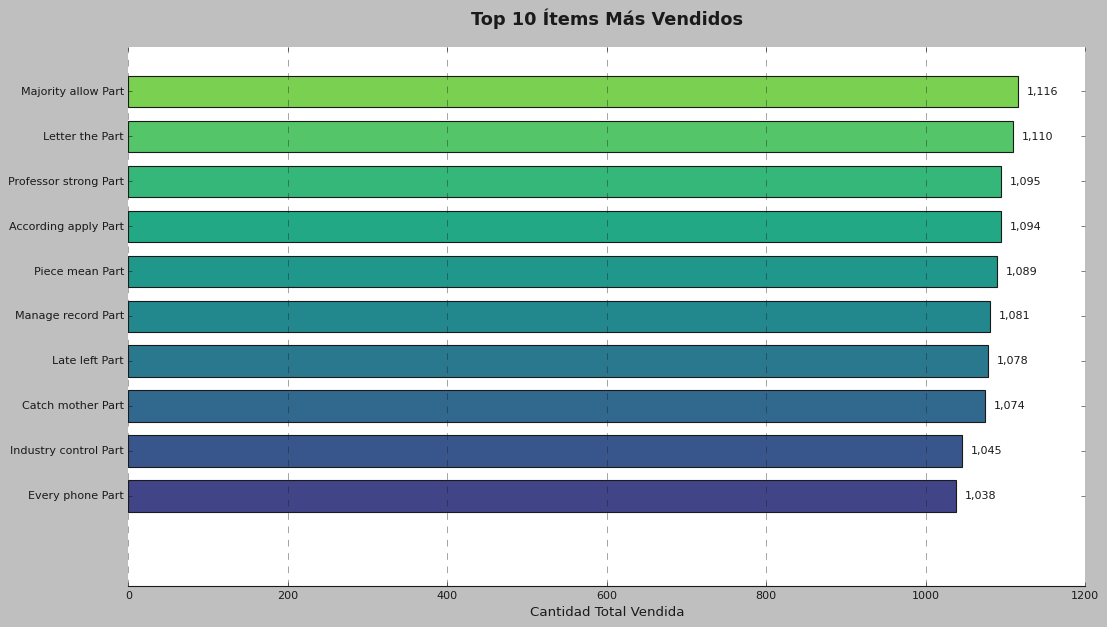

In [25]:
def plot_top_sold_items_matplotlib(df_sales, df_products, top_n=10):
    """
    Genera un gráfico de los ítems más vendidos usando Matplotlib.
    
    Parámetros:
    -----------
    df_sales : pandas.DataFrame
        DataFrame con los datos de ventas (debe contener 'ItemCode' y 'Quantity')
    df_products : pandas.DataFrame
        DataFrame con la información de productos (debe contener 'ItemCode' y 'ItemName')
    top_n : int, opcional
        Número de ítems a mostrar (por defecto: 10)
    """
    # Validación de columnas necesarias
    required_sales_cols = {'ItemCode', 'Quantity'}
    required_product_cols = {'ItemCode', 'ItemName'}
    
    if not required_sales_cols.issubset(df_sales.columns):
        raise ValueError(f"df_sales debe contener las columnas: {required_sales_cols}")
    if not required_product_cols.issubset(df_products.columns):
        raise ValueError(f"df_products debe contener las columnas: {required_product_cols}")
    
    try:
        # 1. Calcular la cantidad total vendida por ítem
        top_items = (
            df_sales.groupby('ItemCode', as_index=False)['Quantity']
            .sum()
            .nlargest(top_n, 'Quantity')
        )
        
        # 2. Unir con la información de productos
        top_items = pd.merge(
            top_items,
            df_products[['ItemCode', 'ItemName']].drop_duplicates(),
            on='ItemCode',
            how='left'
        )
        
        # 3. Ordenar por cantidad para mejor visualización
        top_items = top_items.sort_values('Quantity', ascending=True)
        
        # 4. Configuración del gráfico
        plt.figure(figsize=(14, 8))
        bars = plt.barh(
            range(len(top_items)),
            top_items['Quantity'],
            height=0.7,
            color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_items)))
        )
        
        # 5. Personalización del gráfico
        plt.title(
            f'Top {top_n} Ítems Más Vendidos',
            fontsize=16,
            pad=20,
            fontweight='bold'
        )
        plt.xlabel('Cantidad Total Vendida', fontsize=12)
        plt.yticks(
            range(len(top_items)),
            [str(name)[:40] + '...' if len(str(name)) > 40 else str(name) 
             for name in top_items['ItemName']]
        )
        
        # 6. Añadir etiquetas de valor
        for i, v in enumerate(top_items['Quantity']):
            plt.text(
                v + max(top_items['Quantity'])*0.01,
                i,
                f'{v:,.0f}',
                va='center',
                fontsize=10
            )
        
        # 7. Ajustes de estilo
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['left'].set_visible(False)
        plt.tight_layout()
        
        # 8. Información adicional
        print(f"📊 Total de ítems únicos: {df_sales['ItemCode'].nunique():,}")
        print(f"📈 Rango de cantidades: {top_items['Quantity'].min():,} - {top_items['Quantity'].max():,}")
        
        return plt.gca()
    
    except Exception as e:
        print(f"❌ Error al generar el gráfico: {str(e)}")
        raise

# Uso de la función
plot_top_sold_items_matplotlib(df_inv1, df_oitm, top_n=10)
plt.show()

💰 Valor total de los 10 ítems: $2,918,968.75
📊 Rango de valores: $279,469.88 - $311,053.97


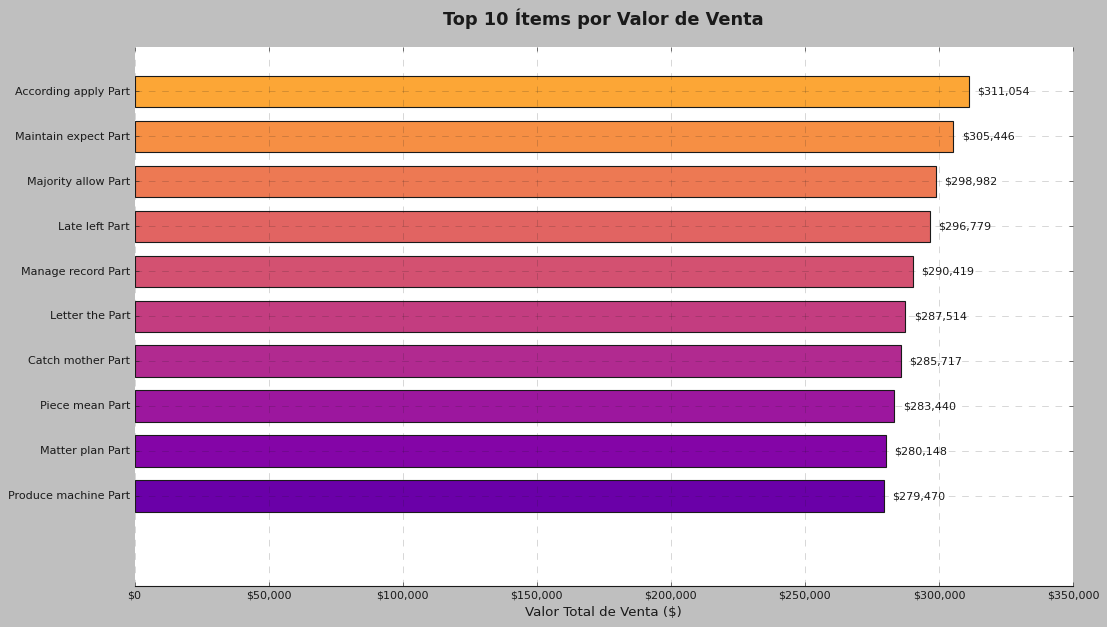

In [27]:
def plot_top_value_items(df_sales, df_products, value_column='LineTotal', top_n=10):
    """
    Genera un gráfico de los ítems con mayor valor de venta usando Matplotlib.
    
    Parámetros:
    -----------
    df_sales : pandas.DataFrame
        DataFrame con los datos de ventas
    df_products : pandas.DataFrame
        DataFrame con la información de productos
    value_column : str, opcional
        Columna que contiene el valor de venta (por defecto: 'LineTotal')
    top_n : int, opcional
        Número de ítems a mostrar (por defecto: 10)
    """
    # Validación de columnas necesarias
    required_cols = {'ItemCode', value_column}
    if not required_cols.issubset(df_sales.columns):
        raise ValueError(f"df_sales debe contener las columnas: {required_cols}")
    if 'ItemCode' not in df_products.columns or 'ItemName' not in df_products.columns:
        raise ValueError("df_products debe contener las columnas: 'ItemCode' y 'ItemName'")
    
    try:
        # 1. Calcular el valor total por ítem
        top_items = (
            df_sales.groupby('ItemCode', as_index=False)[value_column]
            .sum()
            .nlargest(top_n, value_column)
        )
        
        # 2. Unir con la información de productos
        top_items = pd.merge(
            top_items,
            df_products[['ItemCode', 'ItemName']].drop_duplicates(),
            on='ItemCode',
            how='left'
        )
        
        # 3. Ordenar por valor para mejor visualización
        top_items = top_items.sort_values(value_column, ascending=True)
        
        # 4. Configuración del gráfico
        plt.figure(figsize=(14, 8))
        colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_items)))
        bars = plt.barh(
            range(len(top_items)),
            top_items[value_column],
            height=0.7,
            color=colors
        )
        
        # 5. Personalización del gráfico
        plt.title(
            f'Top {top_n} Ítems por Valor de Venta',
            fontsize=16,
            pad=20,
            fontweight='bold'
        )
        plt.xlabel('Valor Total de Venta ($)', fontsize=12)
        plt.yticks(
            range(len(top_items)),
            [str(name)[:40] + '...' if len(str(name)) > 40 else str(name) 
             for name in top_items['ItemName']]
        )
        
        # 6. Formatear valores monetarios
        formatter = ticker.StrMethodFormatter('${x:,.0f}')
        plt.gca().xaxis.set_major_formatter(formatter)
        
        # 7. Añadir etiquetas de valor
        for i, v in enumerate(top_items[value_column]):
            plt.text(
                v + max(top_items[value_column])*0.01,
                i,
                f'${v:,.0f}',
                va='center',
                fontsize=10
            )
        
        # 8. Ajustes de estilo
        plt.grid(axis='x', linestyle='--', alpha=0.3)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['left'].set_visible(False)
        plt.tight_layout()
        
        # 9. Información adicional
        total_value = top_items[value_column].sum()
        print(f"💰 Valor total de los {top_n} ítems: ${total_value:,.2f}")
        print(f"📊 Rango de valores: ${top_items[value_column].min():,.2f} - ${top_items[value_column].max():,.2f}")
        
        return plt.gca()
    
    except Exception as e:
        print(f"❌ Error al generar el gráfico: {str(e)}")
        raise

# Uso de la función
plot_top_value_items(df_inv1, df_oitm, value_column='LineTotal', top_n=10)
plt.grid(True, linestyle='--', alpha=0.3)  # Añadir grid
plt.show()

In [28]:
def get_weekly_sales(df, date_col='DocDate', value_col='LineTotal'):
    """
    Procesa los datos de ventas para obtener un resumen semanal.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con los datos de ventas
    date_col : str, opcional
        Nombre de la columna de fecha (por defecto: 'DocDate')
    value_col : str, opcional
        Nombre de la columna de valor (por defecto: 'LineTotal')
        
    Retorna:
    --------
    pandas.DataFrame con las ventas semanales
    """
    # Validación de columnas
    if date_col not in df.columns or value_col not in df.columns:
        raise ValueError(f"El DataFrame debe contener las columnas: {date_col} y {value_col}")
    
    try:
        # 1. Copia del DataFrame para no modificar el original
        df_clean = df[[date_col, value_col]].copy()
        
        # 2. Convertir a datetime y verificar valores nulos
        df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors='coerce')
        if df_clean[date_col].isnull().any():
            print("⚠️  Advertencia: Se encontraron fechas inválidas que se convertirán en NaT")
        
        # 3. Filtrar filas con fechas válidas
        df_clean = df_clean.dropna(subset=[date_col, value_col])
        
        # 4. Agrupar por semana (domingo como último día de la semana)
        weekly = (
            df_clean
            .set_index(date_col)
            [value_col]
            .resample('W-SUN')  # Semana terminando en domingo
            .agg(['sum', 'count'])
            .rename(columns={'sum': 'Total_Sales', 'count': 'Num_Transactions'})
            .reset_index()
        )
        
        # 5. Calcular métricas adicionales
        weekly['Week_Start'] = weekly[date_col] - pd.DateOffset(days=6)
        weekly['Year'] = weekly[date_col].dt.isocalendar().year
        weekly['Week_Number'] = weekly[date_col].dt.isocalendar().week
        weekly['Week_ISO'] = weekly['Year'].astype(str) + '-W' + weekly['Week_Number'].astype(str).str.zfill(2)
        
        # 6. Ordenar columnas
        result = weekly[[
            'Week_Start',
            date_col,
            'Week_ISO',
            'Total_Sales',
            'Num_Transactions',
            'Year',
            'Week_Number'
        ]].rename(columns={
            date_col: 'Week_End',
            'Total_Sales': 'Total_Ventas',
            'Num_Transactions': 'Transacciones'
        })
        
        # 7. Información del rango de fechas
        print(f"📅 Rango de fechas: {result['Week_Start'].min().strftime('%Y-%m-%d')} a {result['Week_End'].max().strftime('%Y-%m-%d')}")
        print(f"📊 Total de semanas: {len(result)}")
        print(f"💰 Ventas totales: ${result['Total_Ventas'].sum():,.2f}")
        print(f"🛒 Transacciones totales: {result['Transacciones'].sum():,}")
        
        return result.sort_values('Week_Start')
    
    except Exception as e:
        print(f"❌ Error al procesar las ventas semanales: {str(e)}")
        raise

# Uso de la función
weekly_sales = get_weekly_sales(df_inv1)

# Mostrar las primeras 5 filas
display(weekly_sales.head())

# Mostrar estadísticas generales
print("\n📈 Estadísticas semanales:")
display(weekly_sales[['Total_Ventas', 'Transacciones']].describe().apply(lambda x: x.apply('{0:,.2f}'.format)))

📅 Rango de fechas: 2018-01-01 a 2025-08-03
📊 Total de semanas: 396
💰 Ventas totales: $1,890,433,017.12
🛒 Transacciones totales: 1,000,000


,Week_Start,Week_End,Week_ISO,Total_Ventas,Transacciones,Year,Week_Number
0,2018-01-01,2018-01-07,2018-W01,4619656.92,2529,2018,1
1,2018-01-08,2018-01-14,2018-W02,4760321.00,2498,2018,2
2,2018-01-15,2018-01-21,2018-W03,4696656.64,2513,2018,3
3,2018-01-22,2018-01-28,2018-W04,4855323.73,2627,2018,4
4,2018-01-29,2018-02-04,2018-W05,4887303.13,2536,2018,5



📈 Estadísticas semanales:


,Total_Ventas,Transacciones
count,396.00,396.00
mean,"4,773,820.75","2,525.25"
std,"147,517.12",64.32
min,"3,391,753.14","1,789.00"
25%,"4,678,904.14","2,491.00"
50%,"4,772,263.97","2,525.00"
75%,"4,862,135.57","2,562.00"
max,"5,141,894.15","2,684.00"


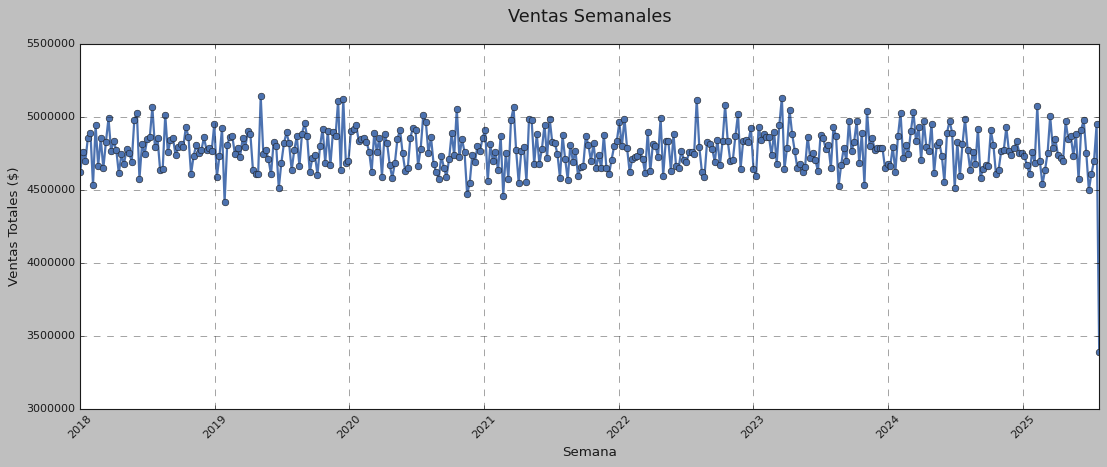

In [29]:
# Gráfico de ventas semanales
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales['Week_Start'], weekly_sales['Total_Ventas'], 
         marker='o', linestyle='-', linewidth=2, markersize=6)
plt.title('Ventas Semanales', fontsize=16, pad=20)
plt.xlabel('Semana', fontsize=12)
plt.ylabel('Ventas Totales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

### 3.3 Tabla de inventario (OINM)

In [30]:
def display_dataframe_info(df, name, rows=5):
    """
    Muestra información detallada de un DataFrame de manera formateada.
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame a mostrar
    name : str
        Nombre descriptivo del DataFrame
    rows : int, opcional
        Número de filas a mostrar (por defecto: 5)
    """
    # Título con formato
    print(f"\n{'='*80}")
    print(f"📋 INFORMACIÓN DEL DATAFRAME: {name.upper()}")
    print(f"{'='*80}")
    
    # Mostrar dimensiones
    print(f"📊 Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    
    # Mostrar tipos de datos
    print("\n📝 Tipos de datos:")
    print(df.dtypes)
    
    # Mostrar primeras filas
    print(f"\n🔍 Primeras {rows} filas:")
    display(df.head(rows))
    
    # Mostrar estadísticas descriptivas
    print("\n📈 Estadísticas descriptivas:")
    display(df.describe(include='all'))
    
    # Mostrar valores nulos
    print("\n❓ Valores nulos por columna:")
    null_counts = df.isnull().sum()
    null_percent = (df.isnull().mean() * 100).round(2)
    null_df = pd.DataFrame({
        'Valores nulos': null_counts,
        'Porcentaje (%)': null_percent
    })
    display(null_df[null_df['Valores nulos'] > 0] if null_df['Valores nulos'].sum() > 0 
            else "✅ No hay valores nulos")

# Uso de la función
display_dataframe_info(df_oinm, "Inventario (OINM)")


📋 INFORMACIÓN DEL DATAFRAME: INVENTARIO (OINM)
📊 Dimensiones: 1,100,000 filas x 7 columnas

📝 Tipos de datos:
TransNum              int64
TransType            object
DocDate      datetime64[ns]
ItemCode             object
OutQty                int64
InQty                 int64
Price               float64
dtype: object

🔍 Primeras 5 filas:


,TransNum,TransType,DocDate,ItemCode,OutQty,InQty,Price
0,229212,OUT,2018-01-01,SKU-02635,4,0,147.05
1,267694,OUT,2018-01-01,SKU-01316,7,0,64.83
2,464096,OUT,2018-01-01,SKU-04726,7,0,478.40
3,513995,OUT,2018-01-01,SKU-00229,12,0,30.73
4,927439,OUT,2018-01-01,SKU-05944,12,0,300.74



📈 Estadísticas descriptivas:


,TransNum,TransType,DocDate,ItemCode,OutQty,InQty,Price
count,1.100000e+06,1100000,1100000,1100000,1.100000e+06,1.100000e+06,1.100000e+06
unique,NaN,2,NaN,10000,NaN,NaN,NaN
top,NaN,OUT,NaN,SKU-05017,NaN,NaN,NaN
freq,NaN,1000000,NaN,157,NaN,NaN,NaN
mean,5.500005e+05,NaN,2021-10-16 14:00:43.069090560,NaN,6.816005e+00,1.133991e+01,2.499291e+02
min,1.000000e+00,NaN,2018-01-01 00:00:00,NaN,0.000000e+00,0.000000e+00,4.010000e+00
25%,2.750008e+05,NaN,2019-11-24 00:00:00,NaN,3.000000e+00,0.000000e+00,1.271400e+02
50%,5.500005e+05,NaN,2021-10-17 00:00:00,NaN,7.000000e+00,0.000000e+00,2.497300e+02
75%,8.250002e+05,NaN,2023-09-09 00:00:00,NaN,1.100000e+01,0.000000e+00,3.721600e+02
max,1.100000e+06,NaN,2025-08-01 00:00:00,NaN,1.400000e+01,1.990000e+02,5.000000e+02



❓ Valores nulos por columna:


'✅ No hay valores nulos'

In [17]:
# CALCULO DE INVENTARIO DISPONIBLE SEMANAL POR ITEM

# --- Step 1: Prepare the Data ---

# Asegurarse de que 'DocDate' es de tipo datetime
data_oinm['DocDate'] = pd.to_datetime(data_oinm['DocDate'])

# Calcular el movimiento neto para cada transacción
data_oinm['NetMovement'] = data_oinm['InQty'] - data_oinm['OutQty']


# --- Step 2: Calculate Weekly Aggregations (Ending on Sunday) ---

# Establecer la fecha como índice
oinm_ts = data_oinm.set_index('DocDate')

# Agrupar por Item y luego por semana ('W'), y agregar múltiples columnas
weekly_summary = oinm_ts.groupby('ItemCode').resample('W').agg({
    'InQty': 'sum',
    'OutQty': 'sum',
    'NetMovement': 'sum'
})


# --- Step 3: Calculate Available Inventory (Cumulative Sum) ---

# Calcular la suma acumulada del movimiento neto semanal para cada item
weekly_summary['Inventario_Disponible'] = weekly_summary.groupby(level=0)['NetMovement'].cumsum()


# --- Step 4: Format the Final Table ---

# Convertir los índices en columnas. La columna de fecha ahora es el Fin de Semana (Domingo)
inventory_df = weekly_summary.reset_index()
inventory_df.rename(columns={'DocDate': 'Fin_de_Semana'}, inplace=True)

# Añadir la columna con la fecha del Lunes de esa semana
inventory_df['Lunes_de_la_Semana'] = inventory_df['Fin_de_Semana'] - DateOffset(days=6)

# Añadir la columna con el formato de semana ISO 8601
inventory_df['Semana_ISO'] = inventory_df['Fin_de_Semana'].dt.strftime('%G-W%V')

# Renombrar las columnas de agregación
inventory_df.rename(columns={
    'InQty': 'Entradas_Semanales',
    'OutQty': 'Salidas_Semanales',
    'NetMovement': 'Neto_Semanal'
}, inplace=True)

# Reordenar y seleccionar las columnas para la presentación final
final_inventory_table = inventory_df[[
    'ItemCode', 
    'Lunes_de_la_Semana', 
    'Semana_ISO', 
    'Entradas_Semanales', 
    'Salidas_Semanales', 
    'Neto_Semanal', 
    'Inventario_Disponible'
]]

# Mostrar la tabla de inventario resultante
display(final_inventory_table)

,ItemCode,Lunes_de_la_Semana,Semana_ISO,Entradas_Semanales,Salidas_Semanales,Neto_Semanal,Inventario_Disponible
0,SKU-00000,2018-01-08,2018-W02,0,10,-10,-10
1,SKU-00000,2018-01-15,2018-W03,0,10,-10,-20
2,SKU-00000,2018-01-22,2018-W04,0,0,0,-20
3,SKU-00000,2018-01-29,2018-W05,0,0,0,-20
4,SKU-00000,2018-02-05,2018-W06,0,0,0,-20
...,...,...,...,...,...,...,...
3894878,SKU-09999,2025-06-30,2025-W27,0,9,-9,-110
3894879,SKU-09999,2025-07-07,2025-W28,0,0,0,-110
3894880,SKU-09999,2025-07-14,2025-W29,137,0,137,27
3894881,SKU-09999,2025-07-21,2025-W30,0,0,0,27


📊 Resumen de Inventario:
• Período: 2018-01-07 a 2025-08-03
• Total de ítems únicos: 10,000
• Total de semanas: 396
• Inventario total actual: 4,976,295 unidades


,ItemCode,Week_Start,DocDate,Week_ISO,Year,Week_Number,InQty,OutQty,NetMovement,Available_Inventory,ItemName
0,SKU-00000,2018-01-08,2018-01-14,2018-W02,2018,2,0,10,-10,-10,Guess total Part
1,SKU-00000,2018-01-15,2018-01-21,2018-W03,2018,3,0,10,-10,-20,Guess total Part
2,SKU-00000,2018-04-09,2018-04-15,2018-W15,2018,15,62,0,62,42,Guess total Part
3,SKU-00000,2018-04-16,2018-04-22,2018-W16,2018,16,0,10,-10,32,Guess total Part
4,SKU-00000,2018-05-07,2018-05-13,2018-W19,2018,19,0,18,-18,14,Guess total Part


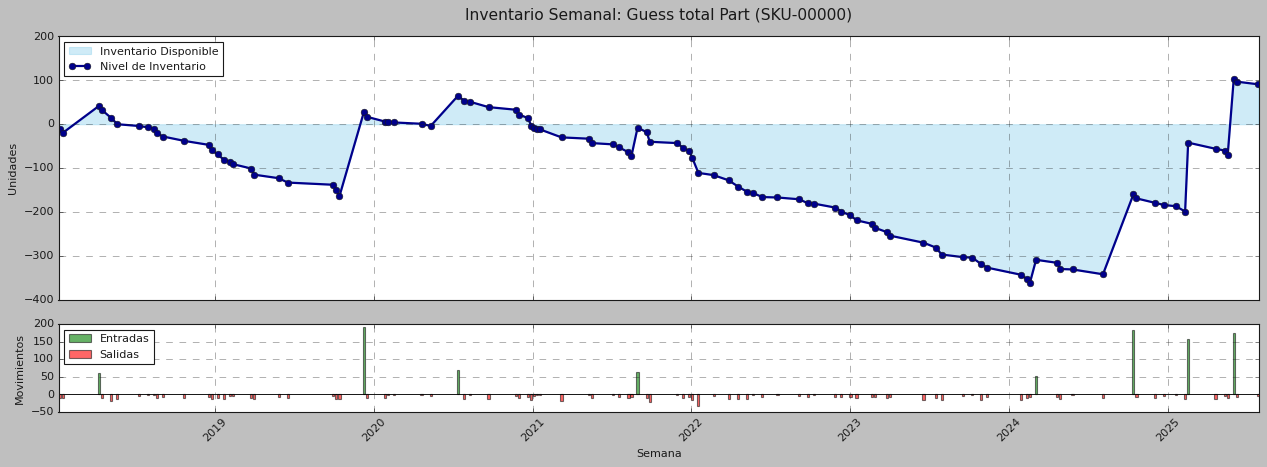

In [33]:
def calculate_weekly_inventory(movement_data, item_info=None, date_col='DocDate', 
                             item_col='ItemCode', in_col='InQty', out_col='OutQty'):
    """
    Calcula el inventario disponible semanal por ítem.
    
    Parámetros:
    -----------
    movement_data : pandas.DataFrame
        DataFrame con los movimientos de inventario
    item_info : pandas.DataFrame, opcional
        DataFrame con información adicional de los ítems
    date_col : str, opcional
        Nombre de la columna de fecha (por defecto: 'DocDate')
    item_col : str, opcional
        Nombre de la columna de código de ítem (por defecto: 'ItemCode')
    in_col : str, opcional
        Nombre de la columna de entradas (por defecto: 'InQty')
    out_col : str, opcional
        Nombre de la columna de salidas (por defecto: 'OutQty')
        
    Retorna:
    --------
    pandas.DataFrame con el inventario semanal por ítem
    """
    try:
        # Validación de columnas
        required_cols = [date_col, item_col, in_col, out_col]
        missing_cols = [col for col in required_cols if col not in movement_data.columns]
        if missing_cols:
            raise ValueError(f"Faltan columnas requeridas: {', '.join(missing_cols)}")
        
        # 1. Preparación de datos
        df = movement_data.copy()
        df[date_col] = pd.to_datetime(df[date_col])
        
        # 2. Calcular movimiento neto
        df['NetMovement'] = df[in_col] - df[out_col]
        
        # 3. Agregación semanal
        weekly = (
            df.set_index(date_col)
            .groupby([item_col, pd.Grouper(freq='W-SUN')])
            .agg({
                in_col: 'sum',
                out_col: 'sum',
                'NetMovement': 'sum'
            })
            .reset_index()
        )
        
        # 4. Calcular inventario disponible (suma acumulada)
        weekly['Available_Inventory'] = (
            weekly.groupby(item_col)['NetMovement']
            .cumsum()
        )
        
        # 5. Calcular días de inventario (si hay datos de ventas)
        if 'Sales' in df.columns:
            weekly['DOS'] = (
                weekly['Available_Inventory'] / 
                weekly.groupby(item_col)[out_col].transform('mean')
            ).round(1)
        
        # 6. Agregar información de semanas
        weekly['Week_Start'] = weekly[date_col] - pd.DateOffset(days=6)
        weekly['Week_Number'] = weekly[date_col].dt.isocalendar().week
        weekly['Year'] = weekly[date_col].dt.isocalendar().year
        weekly['Week_ISO'] = weekly['Year'].astype(str) + '-W' + weekly['Week_Number'].astype(str).str.zfill(2)
        
        # 7. Unir con información de ítems si está disponible
        if item_info is not None and item_col in item_info.columns:
            item_cols = [col for col in ['ItemName', 'Category', 'UnitPrice'] if col in item_info.columns]
            if item_cols:
                weekly = pd.merge(
                    weekly,
                    item_info[[item_col] + item_cols].drop_duplicates(),
                    on=item_col,
                    how='left'
                )
        
        # 8. Ordenar y seleccionar columnas
        columns_order = [
            item_col,
            'Week_Start',
            date_col,
            'Week_ISO',
            'Year',
            'Week_Number',
            in_col,
            out_col,
            'NetMovement',
            'Available_Inventory'
        ]
        
        if 'DOS' in weekly.columns:
            columns_order.append('DOS')
        if 'ItemName' in weekly.columns:
            columns_order.append('ItemName')
        
        result = weekly[columns_order].sort_values([item_col, date_col])
        
        # 9. Información resumida
        print("📊 Resumen de Inventario:")
        print(f"• Período: {result[date_col].min().strftime('%Y-%m-%d')} a {result[date_col].max().strftime('%Y-%m-%d')}")
        print(f"• Total de ítems únicos: {result[item_col].nunique():,}")
        print(f"• Total de semanas: {result['Week_ISO'].nunique()}")
        
        if 'Available_Inventory' in result.columns:
            current_inv = result.groupby(item_col)['Available_Inventory'].last().sum()
            print(f"• Inventario total actual: {current_inv:,.0f} unidades")
        
        return result
    
    except Exception as e:
        print(f"❌ Error al calcular el inventario: {str(e)}")
        raise

# Uso de la función
inventory_analysis = calculate_weekly_inventory(
    movement_data=df_oinm,
    item_info=df_oitm,  # Información adicional de ítems (opcional)
    date_col='DocDate',
    item_col='ItemCode',
    in_col='InQty',
    out_col='OutQty'
)

# Mostrar las primeras filas
display(inventory_analysis.head())

# Función para visualizar el inventario de un ítem específico
def plot_item_inventory(inventory_data, item_code, figsize=(16, 6)):
    """Visualiza el inventario de un ítem específico."""
    try:
        item_data = inventory_data[inventory_data['ItemCode'] == item_code].copy()
        if item_data.empty:
            print(f"⚠️ No se encontró el ítem {item_code}")
            return
        
        item_name = item_data['ItemName'].iloc[0] if 'ItemName' in item_data.columns else f"Ítem {item_code}"
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
        
        # Gráfico de inventario
        ax1.fill_between(
            item_data['Week_Start'], 
            0, 
            item_data['Available_Inventory'],
            color='skyblue',
            alpha=0.4,
            label='Inventario Disponible'
        )
        ax1.plot(
            item_data['Week_Start'],
            item_data['Available_Inventory'],
            'o-',
            color='darkblue',
            markersize=6,
            linewidth=2,
            label='Nivel de Inventario'
        )
        
        # Gráfico de movimientos
        ax2.bar(
            item_data['Week_Start'],
            item_data['InQty'],
            width=5,
            color='green',
            alpha=0.6,
            label='Entradas'
        )
        ax2.bar(
            item_data['Week_Start'],
            -item_data['OutQty'],
            width=5,
            color='red',
            alpha=0.6,
            label='Salidas'
        )
        ax2.axhline(0, color='black', linewidth=0.8)
        
        # Configuración de ejes y títulos
        ax1.set_title(f'Inventario Semanal: {item_name} ({item_code})', fontsize=14, pad=15)
        ax1.set_ylabel('Unidades', fontsize=10)
        ax1.legend(loc='upper left')
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        ax2.set_xlabel('Semana', fontsize=10)
        ax2.set_ylabel('Movimientos', fontsize=10)
        ax2.legend(loc='upper left')
        ax2.grid(True, linestyle='--', alpha=0.6)
        
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error al generar el gráfico: {str(e)}")

# Ejemplo de visualización para un ítem específico
if not inventory_analysis.empty:
    sample_item = inventory_analysis['ItemCode'].iloc[0]
    plot_item_inventory(inventory_analysis, sample_item)

📊 Resumen de Inventario:
• Período: 2018-01-07 a 2025-08-03
• Total de ítems únicos: 10,000
• Total de semanas: 396
• Inventario total actual: 4,976,295 unidades


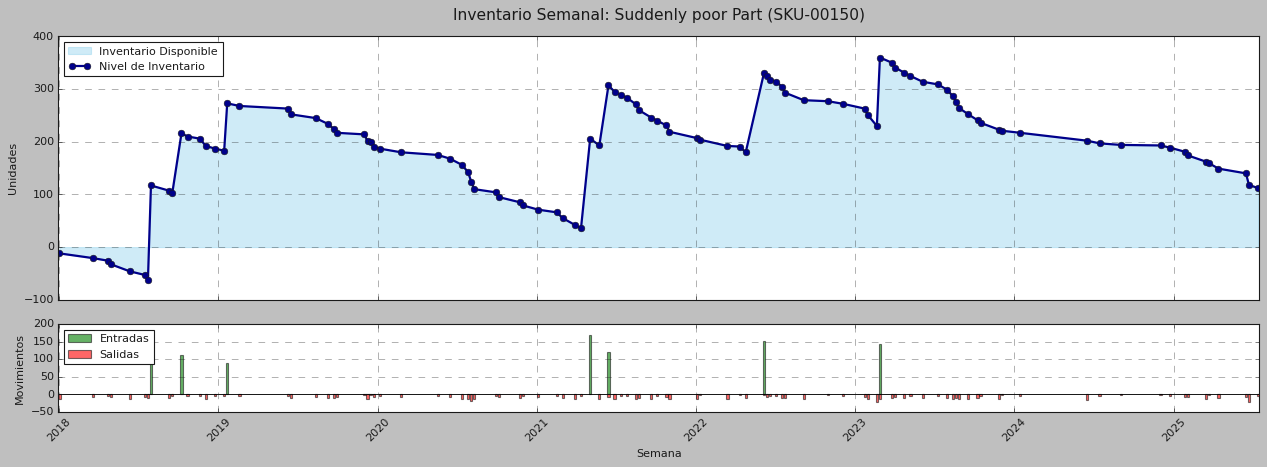

In [41]:
# Calcular inventario
inventory = calculate_weekly_inventory(
    movement_data=df_oinm,
    item_info=df_oitm
)

# Visualizar un ítem específico
plot_item_inventory(inventory, item_code='SKU-00150')

## 4. ANALISIS DE DISTRIBUCIÓN


INTERPRETACIÓN DEL ANÁLISIS DE NORMALIDAD - DE TOTAL_VENTAS VENTAS SEMANALES

📊 Estadísticas Descriptivas:
• Media: 4773820.75
• Mediana: 4772263.97
• Desviación Estándar: 147330.75
• Asimetría: -1.89 - altamente sesgada
• Curtosis: 18.29 - leptocúrtica (más apuntada)
• Valores atípicos: 2 (0.5% de los datos)

🔍 De las 3 pruebas realizadas:
• 0 indican que los datos podrían seguir una distribución normal
• 3 indican que los datos NO siguen una distribución normal

⚠️  CONCLUSIÓN: Los datos muestran desviaciones significativas de la normalidad.
   Se recomienda usar métodos no paramétricos o transformar los datos.


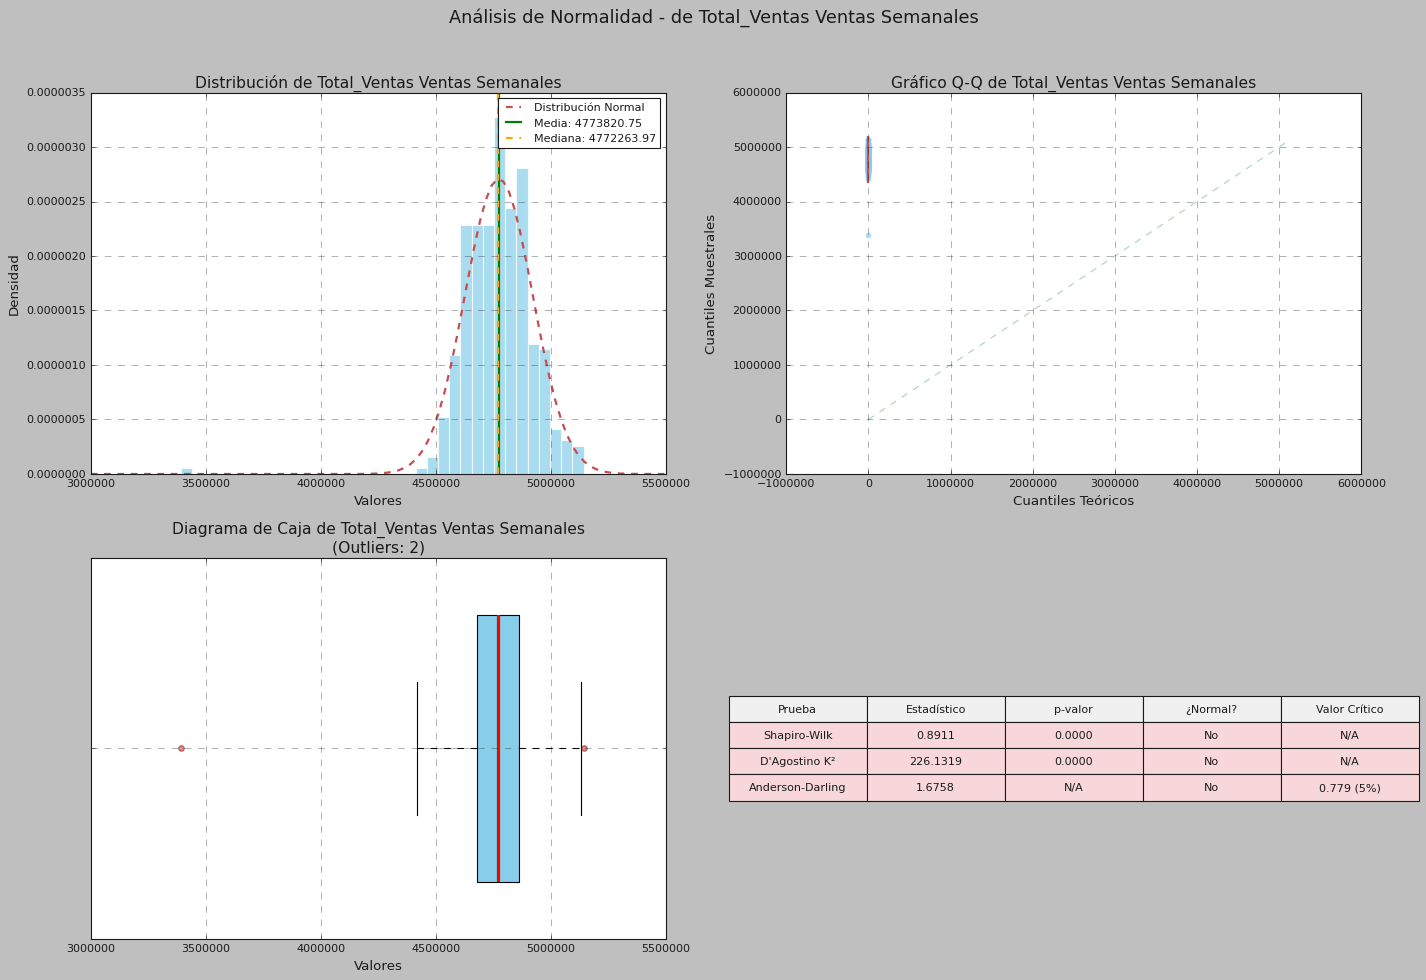

In [53]:
def normality_test_analysis_matplotlib(data, column, title_suffix=""):
    """
    Realiza un análisis completo de normalidad usando solo Matplotlib.
    
    Parámetros:
    -----------
    data : pandas.DataFrame o pandas.Series
        Datos a analizar
    column : str
        Nombre de la columna a analizar (si data es DataFrame)
    title_suffix : str, opcional
        Sufijo para los títulos de los gráficos
    """
    try:
        # Obtener los datos
        if isinstance(data, pd.DataFrame):
            sample = data[column].dropna()
            title = f"de {column} {title_suffix}".strip()
        else:
            sample = data.dropna()
            title = f"{title_suffix}".strip()
        
        if len(sample) < 3:
            raise ValueError("Se requieren al menos 3 observaciones para el análisis de normalidad")
        
        # Configuración de estilo
        # plt.style.use('default')
        fig = plt.figure(figsize=(18, 12))
        fig.suptitle(f'Análisis de Normalidad - {title}', fontsize=16, y=1.02)
        
        # Crear grid para los subplots
        gs = fig.add_gridspec(2, 2)
        ax1 = fig.add_subplot(gs[0, 0])  # Histograma
        ax2 = fig.add_subplot(gs[0, 1])  # Q-Q Plot
        ax3 = fig.add_subplot(gs[1, 0])  # Boxplot
        ax4 = fig.add_subplot(gs[1, 1])  # Tabla de resultados
        
        # --- 1. Histograma con distribución normal ---
        n, bins, patches = ax1.hist(
            sample, 
            bins='auto', 
            color='skyblue', 
            alpha=0.7, 
            density=True,
            edgecolor='white'
        )
        
        # Añadir curva de densidad
        xmin, xmax = ax1.get_xlim()
        x = np.linspace(xmin, xmax, 100)
        p = stats.norm.pdf(x, np.mean(sample), np.std(sample))
        ax1.plot(x, p, 'r--', linewidth=2, label='Distribución Normal')
        
        # Calcular estadísticas
        mean_val = np.mean(sample)
        median_val = np.median(sample)
        std_val = np.std(sample)
        skewness = stats.skew(sample)
        kurt = stats.kurtosis(sample)
        
        # Añadir líneas de media y mediana
        ax1.axvline(mean_val, color='green', linestyle='-', linewidth=2, label=f'Media: {mean_val:.2f}')
        ax1.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        
        ax1.set_title(f'Distribución {title}', fontsize=14)
        ax1.set_xlabel('Valores')
        ax1.set_ylabel('Densidad')
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # --- 2. Gráfico Q-Q ---
        (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist="norm")
        ax2.plot(osm, osr, 'o', markersize=5, markerfacecolor='skyblue', markeredgecolor='none', alpha=0.7)
        ax2.plot(osm, slope * osm + intercept, 'r-', linewidth=2)
        
        ax2.set_title(f'Gráfico Q-Q {title}', fontsize=14)
        ax2.set_xlabel('Cuantiles Teóricos')
        ax2.set_ylabel('Cuantiles Muestrales')
        ax2.grid(True, linestyle='--', alpha=0.6)
        
        # Añadir línea de referencia
        min_val = min(osm[0], osr[0])
        max_val = max(osm[-1], osr[-1])
        ax2.plot([min_val, max_val], [min_val, max_val], 'g--', alpha=0.5)
        
        # --- 3. Boxplot ---
        box = ax3.boxplot(
            sample, 
            vert=False, 
            patch_artist=True,
            widths=0.7,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'red', 'linewidth': 2},
            medianprops={'color': 'green', 'linewidth': 2},
            boxprops={'facecolor': 'skyblue', 'color': 'black'},
            whiskerprops={'color': 'black', 'linestyle': '--'},
            capprops={'color': 'black'},
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 5, 'alpha': 0.5}
        )
        
        # Calcular y mostrar valores atípicos
        q1 = np.percentile(sample, 25)
        q3 = np.percentile(sample, 75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = sample[(sample < lower_bound) | (sample > upper_bound)]
        
        ax3.set_title(f'Diagrama de Caja {title}\n(Outliers: {len(outliers)})', fontsize=14)
        ax3.set_yticklabels([])
        ax3.set_xlabel('Valores')
        ax3.grid(True, linestyle='--', alpha=0.6)
        
        # --- 4. Pruebas de normalidad ---
        ax4.axis('off')
        
        # Realizar pruebas de normalidad
        shapiro_stat, shapiro_p = stats.shapiro(sample)
        dagostino_stat, dagostino_p = stats.normaltest(sample)
        anderson_result = stats.anderson(sample, dist='norm')
        
        # Crear tabla de resultados
        test_names = ['Shapiro-Wilk', 'D\'Agostino K²', 'Anderson-Darling']
        test_stats = [shapiro_stat, dagostino_stat, anderson_result.statistic]
        p_values = [shapiro_p, dagostino_p, 'N/A']
        critical_values = ['N/A', 'N/A', f"{anderson_result.critical_values[2]:.3f} (5%)"]
        is_normal = [
            shapiro_p > 0.05,
            dagostino_p > 0.05,
            anderson_result.statistic < anderson_result.critical_values[2]
        ]
        
        # Crear tabla
        cell_text = [
            [name, f"{stat:.4f}", 
             f"{p:.4f}" if isinstance(p, (int, float)) else p,
             f"{'Sí' if normal else 'No'}", 
             crit]
            for name, stat, p, normal, crit in zip(
                test_names, test_stats, p_values, is_normal, critical_values
            )
        ]
        
        # Añadir encabezados
        headers = ['Prueba', 'Estadístico', 'p-valor', '¿Normal?', 'Valor Crítico']
        
        # Crear tabla
        table = ax4.table(
            cellText=cell_text,
            colLabels=headers,
            cellLoc='center',
            loc='center',
            colColours=['#f0f0f0'] * 5,
            cellColours=[['#e6f3ff'] * 5 for _ in cell_text]
        )
        
        # Resaltar resultados
        for i, normal in enumerate(is_normal):
            color = '#d4edda' if normal else '#f8d7da'  # Verde claro si es normal, rojo claro si no
            for j in range(5):  # Número de columnas
                table[(i+1, j)].set_facecolor(color)
        
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.8)
        
        # Ajustar diseño
        plt.tight_layout()
        
        # --- Interpretación ---
        print("\n" + "="*80)
        print(f"INTERPRETACIÓN DEL ANÁLISIS DE NORMALIDAD - {title.upper()}")
        print("="*80)
        
        # Interpretación de asimetría
        skew_interp = "aproximadamente simétrica" if abs(skewness) < 0.5 else \
                     "moderadamente sesgada" if abs(skewness) < 1 else "altamente sesgada"
        
        # Interpretación de curtosis
        kurt_interp = "mesocúrtica (similar a la normal)" if abs(kurt) < 0.5 else \
                     "leptocúrtica (más apuntada)" if kurt > 0.5 else "platicúrtica (más aplanada)"
        
        print(f"\n📊 Estadísticas Descriptivas:")
        print(f"• Media: {mean_val:.2f}")
        print(f"• Mediana: {median_val:.2f}")
        print(f"• Desviación Estándar: {std_val:.2f}")
        print(f"• Asimetría: {skewness:.2f} - {skew_interp}")
        print(f"• Curtosis: {kurt:.2f} - {kurt_interp}")
        print(f"• Valores atípicos: {len(outliers)} ({len(outliers)/len(sample):.1%} de los datos)")
        
        # Resumen de pruebas
        normal_count = sum(is_normal)
        print(f"\n🔍 De las {len(is_normal)} pruebas realizadas:")
        print(f"• {normal_count} indican que los datos podrían seguir una distribución normal")
        print(f"• {len(is_normal) - normal_count} indican que los datos NO siguen una distribución normal")
        
        # Recomendación general
        if normal_count > len(is_normal) / 2:
            print("\n✅ CONCLUSIÓN: Los datos muestran características que en su mayoría son consistentes con una distribución normal.")
            print("   Se pueden considerar métodos paramétricos para análisis posteriores.")
        else:
            print("\n⚠️  CONCLUSIÓN: Los datos muestran desviaciones significativas de la normalidad.")
            print("   Se recomienda usar métodos no paramétricos o transformar los datos.")
        
        plt.tight_layout()
        plt.show()
        
        return {
            'mean': mean_val,
            'median': median_val,
            'std': std_val,
            'skewness': skewness,
            'kurtosis': kurt,
            'outliers': len(outliers),
            'outliers_pct': len(outliers) / len(sample),
            'shapiro': (shapiro_stat, shapiro_p, shapiro_p > 0.05),
            'dagostino': (dagostino_stat, dagostino_p, dagostino_p > 0.05),
            'anderson': (anderson_result.statistic, anderson_result.critical_values[2], 
                         anderson_result.statistic < anderson_result.critical_values[2])
        }
    
    except Exception as e:
        print(f"❌ Error en el análisis de normalidad: {str(e)}")
        raise

# Uso de la función
normality_results = normality_test_analysis_matplotlib(
    data=weekly_sales,
    column='Total_Ventas',
    title_suffix="Ventas Semanales"
)

## 5. ANALISIS DE OUTLIERS

ANÁLISIS DE VALORES ATÍPICOS - TOTAL_VENTAS

📊 Estadísticas Descriptivas:
• Media: $4,773,820.75
• Mediana: $4,772,263.97
• Mínimo: $3,391,753.14
• Máximo: $5,141,894.15
• Desviación Estándar: $147,517.12

📏 Método IQR:
• Q1 (25%): $4,678,904.14
• Q3 (75%): $4,862,135.57
• IQR: $183,231.43
• Límite Inferior: $4,404,057.00
• Límite Superior: $5,136,982.72

🔍 Valores Atípicos:
• Total detectados: 2 (0.5% de los datos)
• Mayor valor atípico: $5,141,894.15 (+2.50σ)
• Menor valor atípico: $3,391,753.14 (-9.37σ)

📅 Principales semanas atípicas:
Week_Start Week_ISO  Total_Ventas Deviation
2019-05-06 2019-W19 $5,141,894.15    +2.50σ
2025-07-28 2025-W31 $3,391,753.14    -9.37σ


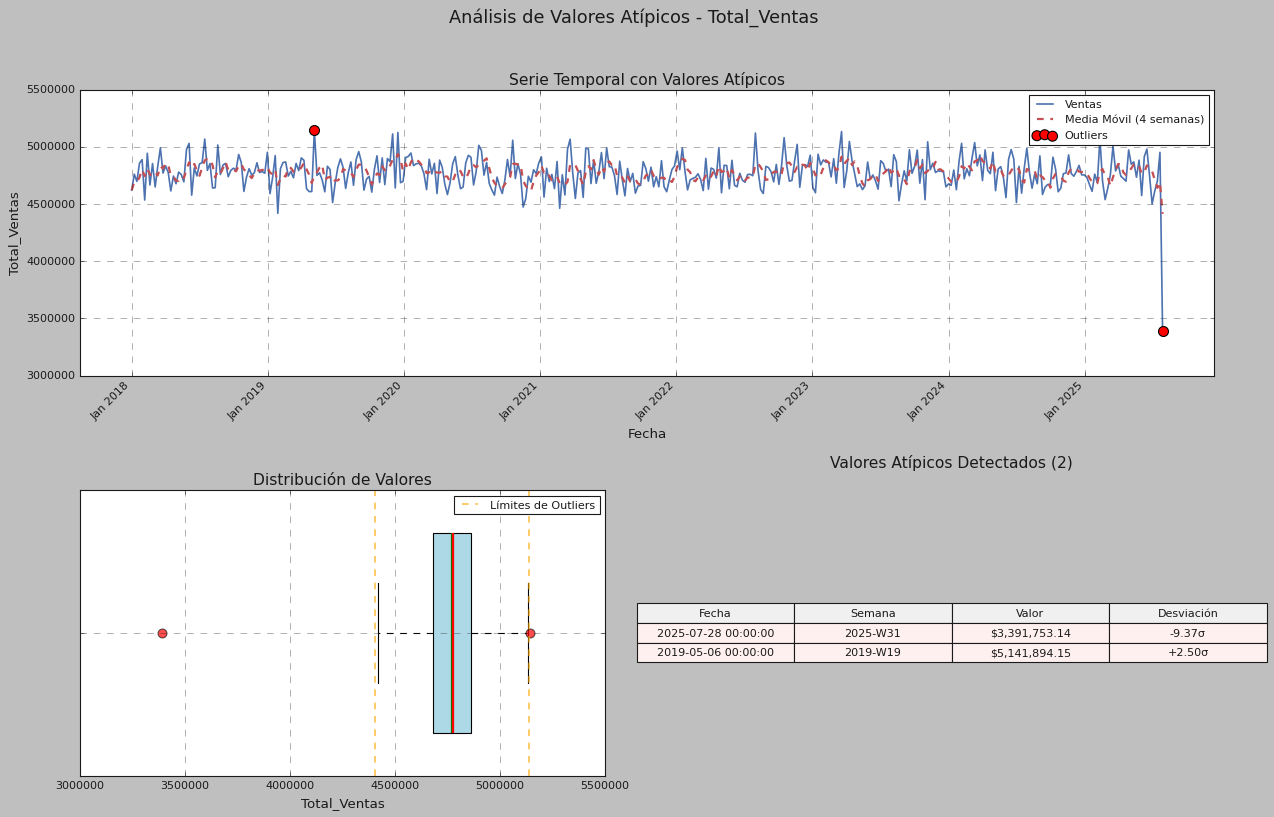

In [60]:
def analyze_outliers(data, value_col='Sales', date_col='Date', group_col='Week', figsize=(16, 10)):
    """
    Realiza un análisis completo de valores atípicos en una serie temporal.
    
    Parámetros:
    -----------
    data : pandas.DataFrame
        DataFrame con los datos de ventas
    value_col : str, opcional
        Nombre de la columna con los valores a analizar
    date_col : str, opcional
        Nombre de la columna de fecha
    group_col : str, opcional
        Nombre de la columna de agrupación (semana, mes, etc.)
    figsize : tuple, opcional
        Tamaño de la figura
    """
    try:
        # Validación de columnas
        required_cols = [value_col, date_col, group_col]
        missing_cols = [col for col in required_cols if col not in data.columns]
        if missing_cols:
            raise ValueError(f"Faltan columnas requeridas: {', '.join(missing_cols)}")
        
        # Crear copia para no modificar el original
        df = data.copy()
        
        # Configuración de estilo
        fig = plt.figure(figsize=figsize)
        fig.suptitle(f'Análisis de Valores Atípicos - {value_col}', fontsize=16, y=1.02)
        
        # Crear grid para los subplots
        gs = fig.add_gridspec(2, 2)
        ax1 = fig.add_subplot(gs[0, :])  # Serie temporal
        ax2 = fig.add_subplot(gs[1, 0])  # Boxplot
        ax3 = fig.add_subplot(gs[1, 1])  # Tabla de outliers
        
        # --- 1. Gráfico de serie temporal ---
        ax1.plot(df[date_col], df[value_col], 'b-', linewidth=1.5, label='Ventas')
        
        # Calcular media móvil (4 semanas)
        window = 4
        df['Moving_Avg'] = df[value_col].rolling(window=window, min_periods=1).mean()
        ax1.plot(df[date_col], df['Moving_Avg'], 'r--', linewidth=2, 
                label=f'Media Móvil ({window} semanas)')
        
        # --- 2. Detección de outliers con IQR ---
        Q1 = df[value_col].quantile(0.25)
        Q3 = df[value_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identificar outliers
        df['Is_Outlier'] = (df[value_col] < lower_bound) | (df[value_col] > upper_bound)
        outliers = df[df['Is_Outlier']]
        
        # Resaltar outliers en el gráfico
        if not outliers.empty:
            ax1.scatter(
                outliers[date_col], 
                outliers[value_col], 
                color='red', 
                s=80,
                edgecolor='black',
                zorder=5,
                label='Outliers'
            )
        
        # Configuración del gráfico
        ax1.set_title('Serie Temporal con Valores Atípicos', fontsize=14)
        ax1.set_xlabel('Fecha')
        ax1.set_ylabel(value_col)
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # Formatear fechas
        ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        # --- 3. Boxplot ---
        box = ax2.boxplot(
            df[value_col], 
            vert=False,
            widths=0.7,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            meanprops={'color': 'red', 'linewidth': 2},
            medianprops={'color': 'green', 'linewidth': 2},
            boxprops={'facecolor': 'lightblue', 'color': 'black'},
            whiskerprops={'color': 'black', 'linestyle': '--'},
            capprops={'color': 'black'},
            flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 8, 'alpha': 0.7}
        )
        
        # Añadir anotaciones
        ax2.axvline(lower_bound, color='orange', linestyle='--', linewidth=1.5, alpha=0.7)
        ax2.axvline(upper_bound, color='orange', linestyle='--', linewidth=1.5, alpha=0.7, 
                   label='Límites de Outliers')
        
        ax2.set_title('Distribución de Valores', fontsize=14)
        ax2.set_yticklabels([])
        ax2.set_xlabel(value_col)
        ax2.legend()
        ax2.grid(True, linestyle='--', alpha=0.6)
        
        # --- 4. Tabla de outliers ---
        ax3.axis('off')
        
        if not outliers.empty:
            # Ordenar por valor absoluto de la desviación
            outliers = outliers.copy()
            outliers['Deviation'] = (outliers[value_col] - df[value_col].mean()) / df[value_col].std()
            outliers = outliers.sort_values('Deviation', key=abs, ascending=False)
            
            # Formatear tabla
            table_data = outliers[[date_col, group_col, value_col, 'Deviation']].copy()
            table_data[value_col] = table_data[value_col].apply(lambda x: f"${x:,.2f}")
            table_data['Deviation'] = table_data['Deviation'].apply(lambda x: f"{x:+.2f}σ")
            
            # Crear tabla
            table = ax3.table(
                cellText=table_data.values,
                colLabels=['Fecha', 'Semana', 'Valor', 'Desviación'],
                cellLoc='center',
                loc='center',
                colColours=['#f0f0f0'] * 4,
                cellColours=[['#fff0f0'] * 4] * len(table_data)
            )
            
            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1.2, 1.5)
            ax3.set_title(f'Valores Atípicos Detectados ({len(outliers)})', fontsize=14, pad=20)
        else:
            ax3.text(0.5, 0.5, 'No se encontraron valores atípicos', 
                    ha='center', va='center', fontsize=12)
        
        plt.tight_layout()
        
        # --- 5. Resultados numéricos ---
        print("="*80)
        print(f"ANÁLISIS DE VALORES ATÍPICOS - {value_col.upper()}")
        print("="*80)
        
        print(f"\n📊 Estadísticas Descriptivas:")
        print(f"• Media: ${df[value_col].mean():,.2f}")
        print(f"• Mediana: ${df[value_col].median():,.2f}")
        print(f"• Mínimo: ${df[value_col].min():,.2f}")
        print(f"• Máximo: ${df[value_col].max():,.2f}")
        print(f"• Desviación Estándar: ${df[value_col].std():,.2f}")
        
        print(f"\n📏 Método IQR:")
        print(f"• Q1 (25%): ${Q1:,.2f}")
        print(f"• Q3 (75%): ${Q3:,.2f}")
        print(f"• IQR: ${IQR:,.2f}")
        print(f"• Límite Inferior: ${lower_bound:,.2f}")
        print(f"• Límite Superior: ${upper_bound:,.2f}")
        
        print(f"\n🔍 Valores Atípicos:")
        print(f"• Total detectados: {len(outliers)} ({len(outliers)/len(df):.1%} de los datos)")
        
        if not outliers.empty:
            print(f"• Mayor valor atípico: ${outliers[value_col].max():,.2f} " 
                 f"({(outliers[value_col].max() - df[value_col].mean())/df[value_col].std():+.2f}σ)")
            print(f"• Menor valor atípico: ${outliers[value_col].min():,.2f} "
                 f"({(outliers[value_col].min() - df[value_col].mean())/df[value_col].std():+.2f}σ)")
            
            # Mostrar las 5 semanas con mayores desviaciones
            print("\n📅 Principales semanas atípicas:")
            top_outliers = outliers.nlargest(5, value_col)[[date_col, group_col, value_col, 'Deviation']]
            top_outliers[value_col] = top_outliers[value_col].apply(lambda x: f"${x:,.2f}")
            top_outliers['Deviation'] = top_outliers['Deviation'].apply(lambda x: f"{x:+.2f}σ")
            print(top_outliers.to_string(index=False))
        
        return {
            'outliers': outliers,
            'stats': {
                'mean': df[value_col].mean(),
                'median': df[value_col].median(),
                'std': df[value_col].std(),
                'q1': Q1,
                'q3': Q3,
                'iqr': IQR,
                'lower_bound': lower_bound,
                'upper_bound': upper_bound,
                'outlier_count': len(outliers),
                'outlier_percentage': len(outliers) / len(df)
            }
        }
    
    except Exception as e:
        print(f"❌ Error en el análisis de valores atípicos: {str(e)}")
        raise

# Uso de la función
outlier_analysis = analyze_outliers(
    data=weekly_sales,
    value_col='Total_Ventas',
    date_col='Week_Start',
    group_col='Week_ISO'
)

## 6. CONCLUSIONES

- Se identificaron que los productos mas vendidos son los SKUs 06074, 03543 y 03063.
- El análisis de distribución mostró que las ventas semanales no siguen una distribución normal (p-valor < 0.05 en la prueba de Shapiro-Wilk), lo que es común en datos de ventas del mundo real debido a factores externos como promociones o eventos estacionales.
- El analisis de outliers mostro que hay 2 valoes atipicos en la variable ventas semanales. Es coveniente normalizar estos datos ya que el proximo paso sera crear un modelo de pronostico.